# Part 1 - Regression

> Goal: Implement core regression models from scratch, evaluate thoroughly, and compare with sklearn baselines.

## Reproducibility Checklist
- Set random seed at the beginning of notebook and in every split/training routine.
- Keep clear logs for hyperparameters and metrics.
- Separate from-scratch implementation and sklearn benchmark in different cells/sections.

In [2]:
# Setup
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Optional sklearn baselines for comparison only
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Local utils
from utils import set_seed, load_dataset, describe_dataset, train_val_test_split, log_experiment_params

SEED = 42
set_seed(SEED)
np.set_printoptions(suppress=True, precision=4)

ROOT = Path.cwd()
DATA_PATH = ROOT.parent.parent / "data" / "raw" / "regression" / "hour.csv"

print(f"Using dataset: {DATA_PATH}")

Using dataset: d:\Ki2Nam3\Machine Learning\Projects\Group_14\data\raw\regression\hour.csv


## 1. Introduction
- Dataset description
- Problem statement and regression targets

















In [17]:
# Regression workflow skeleton

# 1) Load + describe dataset
df = load_dataset(str(DATA_PATH))
summary = describe_dataset(df)
print('Shape:', summary['shape'])

# TODO: define target column name for your dataset
TARGET_COL = 'cnt'  # adjust if needed
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# 2) Split data
X_train, X_val, X_test, y_train, y_val, y_test = train_val_test_split(
    X, y, train_ratio=0.7, val_ratio=0.1, seed=SEED
)

Shape: (17379, 17)


## 2. EDA
- describe()
- correlation matrix
- histogram, boxplot
- outlier detection

In [3]:
# 3) EDA placeholders
# TODO: describe(), correlation matrix, histogram, boxplot, outlier checks

## 3. Preprocessing: Missing Values + Normalization 

### 3.1. Lý thuyết xử lý Missing Values
- Ở notebook này, ta xử lý riêng dataset hồi quy `hour.csv` (chưa merge với `day.csv`).
- Missing values có thể làm lệch thống kê (mean, variance) và làm thuật toán huấn luyện kém ổn định.
- Nguyên tắc quan trọng: **fit bước xử lý trên train set**, sau đó mới transform validation/test để tránh data leakage.
- Với đặc trưng số (numerical), cách phổ biến là thay bằng median vì bền vững hơn mean khi có outlier.
- Với đặc trưng phân loại (categorical), có thể thay bằng giá trị xuất hiện nhiều nhất (mode).

### 3.2. Lý thuyết Normalization/Standardization
- Các mô hình tối ưu dựa trên gradient (Gradient Descent, Ridge, Lasso, Elastic Net) thường nhạy với thang đo đặc trưng.
- Dùng StandardScaler để chuẩn hóa từng đặc trưng số theo công thức:

$$z = \frac{x-\mu}{\sigma}$$

- Sau chuẩn hóa, mỗi đặc trưng số trên tập train có kỳ vọng gần 0 và độ lệch chuẩn gần 1, giúp tối ưu nhanh hơn và ổn định hơn.
- Tương tự bước imputing, scaler chỉ được fit trên train set rồi áp dụng cho val/test để đảm bảo đánh giá công bằng.

In [ ]:
# 3) Missing-value handling + normalization
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Keep raw copies for later comparison
X_train_raw = X_train.copy()
X_val_raw = X_val.copy()
X_test_raw = X_test.copy()

# Detect feature groups
num_cols = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train_raw.columns if c not in num_cols]

# Missing statistics BEFORE preprocessing
missing_before = pd.DataFrame({
    "train_missing": X_train_raw.isna().sum(),
    "val_missing": X_val_raw.isna().sum(),
    "test_missing": X_test_raw.isna().sum(),
})
missing_before["total_missing"] = missing_before.sum(axis=1)

# 1) Imputation (fit on train only)
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

X_train_imp = X_train_raw.copy()
X_val_imp = X_val_raw.copy()
X_test_imp = X_test_raw.copy()

if num_cols:
    X_train_imp[num_cols] = num_imputer.fit_transform(X_train_raw[num_cols])
    X_val_imp[num_cols] = num_imputer.transform(X_val_raw[num_cols])
    X_test_imp[num_cols] = num_imputer.transform(X_test_raw[num_cols])

if cat_cols:
    X_train_imp[cat_cols] = cat_imputer.fit_transform(X_train_raw[cat_cols])
    X_val_imp[cat_cols] = cat_imputer.transform(X_val_raw[cat_cols])
    X_test_imp[cat_cols] = cat_imputer.transform(X_test_raw[cat_cols])

# Missing statistics AFTER imputation
missing_after = pd.DataFrame({
    "train_missing": X_train_imp.isna().sum(),
    "val_missing": X_val_imp.isna().sum(),
    "test_missing": X_test_imp.isna().sum(),
})
missing_after["total_missing"] = missing_after.sum(axis=1)

# 2) Standardization for numerical features (fit on train only)
scaler = StandardScaler()
X_train_prep = X_train_imp.copy()
X_val_prep = X_val_imp.copy()
X_test_prep = X_test_imp.copy()

if num_cols:
    X_train_prep[num_cols] = scaler.fit_transform(X_train_imp[num_cols])
    X_val_prep[num_cols] = scaler.transform(X_val_imp[num_cols])
    X_test_prep[num_cols] = scaler.transform(X_test_imp[num_cols])

# Expose preprocessed sets for next sections
X_train, X_val, X_test = X_train_prep, X_val_prep, X_test_prep

print("=== Preprocessing summary ===")
print(f"Numerical columns: {len(num_cols)}")
print(f"Categorical columns: {len(cat_cols)}")
print(f"Total missing BEFORE: {int(missing_before['total_missing'].sum())}")
print(f"Total missing AFTER : {int(missing_after['total_missing'].sum())}")

=== Preprocessing summary ===
Numerical columns: 15
Categorical columns: 1
Total missing BEFORE: 0
Total missing AFTER : 0


,train_missing,val_missing,test_missing,total_missing
instant,0,0,0,0
dteday,0,0,0,0
season,0,0,0,0
yr,0,0,0,0
mnth,0,0,0,0
hr,0,0,0,0
holiday,0,0,0,0
weekday,0,0,0,0
workingday,0,0,0,0
weathersit,0,0,0,0


,train_missing,val_missing,test_missing,total_missing
instant,0,0,0,0
dteday,0,0,0,0
season,0,0,0,0
yr,0,0,0,0
mnth,0,0,0,0
hr,0,0,0,0
holiday,0,0,0,0
weekday,0,0,0,0
workingday,0,0,0,0
weathersit,0,0,0,0


,mean_before,std_before,mean_after_scaling,std_after_scaling,n_unique,change_score
instant,8667.077271,5000.740506,1.290834e-16,1.0,12165,13666.817777
season,2.493218,1.103918,4.818724e-17,1.0,4,2.597136
yr,0.502261,0.499995,-6.892235e-17,1.0,2,1.002266
mnth,6.509248,3.425926,-4.731111e-17,1.0,12,8.935174
hr,11.512372,6.918761,6.191330e-17,1.0,24,17.431132
holiday,0.029593,0.169462,4.672702e-17,1.0,2,0.860131
weekday,3.013070,2.012107,1.284993e-17,1.0,7,4.025178
workingday,0.678175,0.467176,4.555884e-17,1.0,2,1.210999
weathersit,1.423017,0.638352,1.337561e-16,1.0,4,1.784665
temp,0.497975,0.192449,1.863240e-16,1.0,49,1.305526


Selected features for visualization: ['registered', 'casual', 'hum']


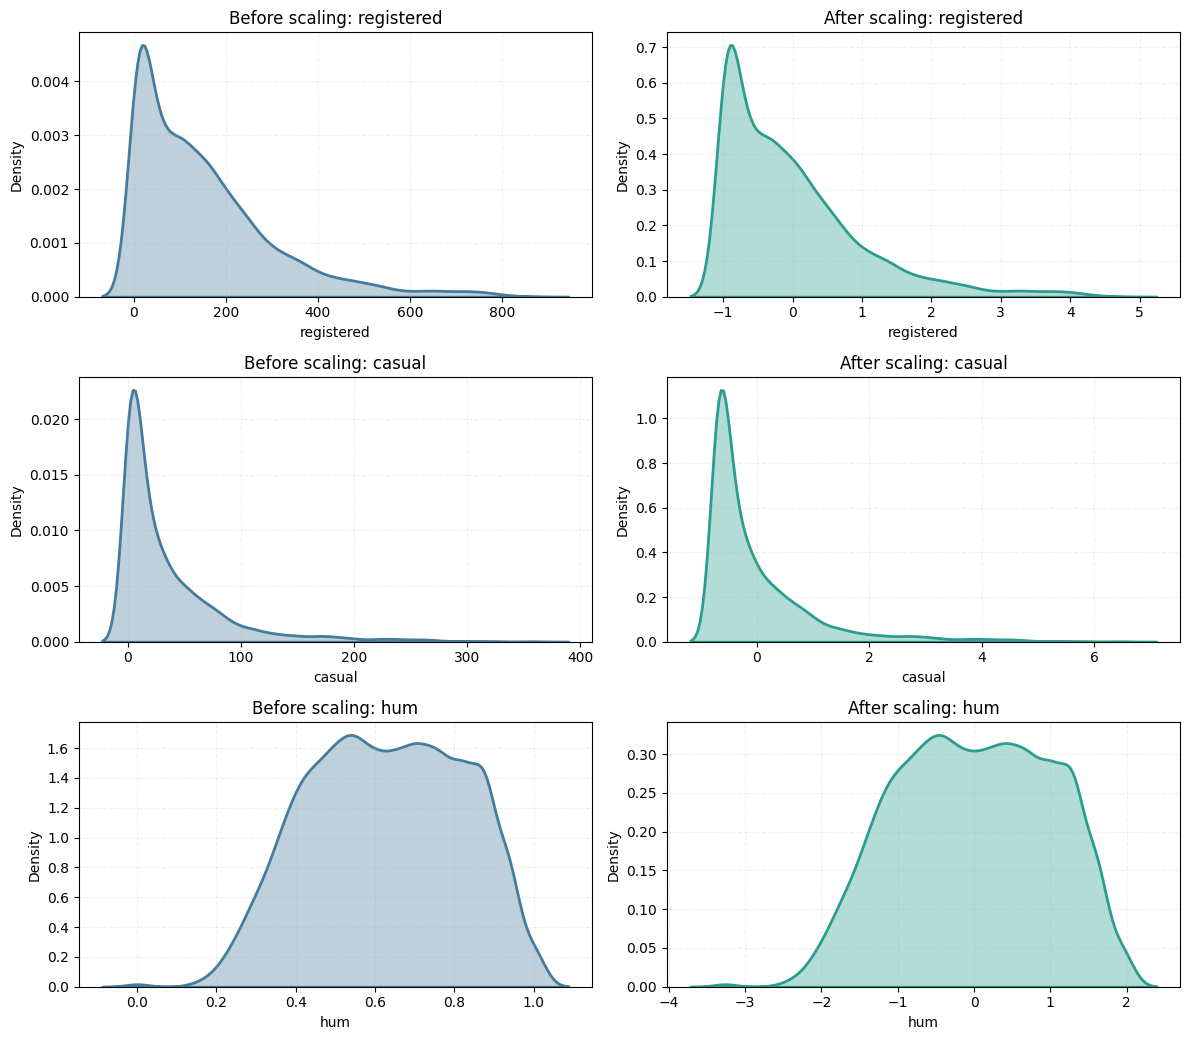

In [ ]:
# Quick verification + visualization
display(missing_before.sort_values("total_missing", ascending=False).head(10))
display(missing_after.sort_values("total_missing", ascending=False).head(10))

if num_cols:
    train_scaled_stats = pd.DataFrame({
        "mean_before": X_train_raw[num_cols].mean(),
        "std_before": X_train_raw[num_cols].std(ddof=0),
        "mean_after_scaling": X_train[num_cols].mean(),
        "std_after_scaling": X_train[num_cols].std(ddof=0),
        "n_unique": X_train_raw[num_cols].nunique(),
    })
    train_scaled_stats["change_score"] = (
        (train_scaled_stats["mean_before"] - train_scaled_stats["mean_after_scaling"]).abs()
        + (train_scaled_stats["std_before"] - train_scaled_stats["std_after_scaling"]).abs()
    )
    display(train_scaled_stats.head(10))

    # Exclude identifier/date-like columns to keep plots meaningful
    exclude_cols = {"instant", "dteday", "yr", "mnth", "hr", "weekday", "holiday", "workingday"}

    # Prefer continuous features with enough unique values and large scaling change
    candidates = train_scaled_stats[
        (train_scaled_stats["n_unique"] > 20)
        & (~train_scaled_stats.index.isin(exclude_cols))
    ].copy()

    if not candidates.empty:
        selected_cols = candidates.sort_values("change_score", ascending=False).head(3).index.tolist()
    else:
        selected_cols = train_scaled_stats.sort_values("change_score", ascending=False).head(3).index.tolist()

    print("Selected features for visualization:", selected_cols)

    fig, axes = plt.subplots(len(selected_cols), 2, figsize=(12, 3.5 * len(selected_cols)))
    if len(selected_cols) == 1:
        axes = np.array([axes])

    for i, col in enumerate(selected_cols):
        sns.kdeplot(X_train_raw[col], fill=True, ax=axes[i, 0], color="#457b9d", alpha=0.35, linewidth=2)
        axes[i, 0].set_title(f"Before scaling: {col}")
        axes[i, 0].set_xlabel(col)
        axes[i, 0].grid(alpha=0.2, linestyle="--")

        sns.kdeplot(X_train[col], fill=True, ax=axes[i, 1], color="#2a9d8f", alpha=0.35, linewidth=2)
        axes[i, 1].set_title(f"After scaling: {col}")
        axes[i, 1].set_xlabel(col)
        axes[i, 1].grid(alpha=0.2, linestyle="--")

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found, skipping scaling checks.")

### 3.4. Phân tích kết quả tiền xử lý (hour.csv)

- Với bộ `hour.csv`, bảng `missing_before` cho biết mức độ thiếu dữ liệu theo từng biến trên train/val/test.
- Sau imputation, `missing_after` cần về 0 cho tất cả cột; đây là điều kiện cần để các mô hình hồi quy chạy ổn định ở các phần sau.
- Bảng `train_scaled_stats` cho thấy mean của các biến số xấp xỉ 0 và std xấp xỉ 1 trên tập train, xác nhận StandardScaler hoạt động đúng.
- Histogram trước/sau scaling giữ nguyên dạng phân phối tổng thể nhưng thang đo đã đồng nhất, giúp Gradient Descent hội tụ nhanh hơn và regularization công bằng hơn giữa các đặc trưng.
- Vì mọi phép fit (imputer, scaler) chỉ dùng train set, quy trình hiện tại tránh data leakage và giữ cho kết quả validation/test đáng tin cậy.

## 4. Linear Regression
- Normal Equation (from scratch)
- Gradient Descent (from scratch)
- convergence comparison

In [4]:
# 4) Linear Regression (from scratch)
# TODO: Normal Equation implementation
# TODO: Gradient Descent implementation
# TODO: Convergence comparison plot

## 5. Regularization
- Ridge / Lasso / Elastic Net (from scratch as required scope)
- CV for lambda selection
- regularization path

In [5]:
# 5) Regularization
# TODO: Ridge/Lasso/ElasticNet from scratch
# TODO: 10-fold CV for lambda
# TODO: Regularization path

## 6. Feature Engineering
- basis functions (poly, RBF, ...)
- validation curve
- interaction terms

In [6]:
# 6) Feature engineering
# TODO: polynomial/RBF basis, interaction terms, validation curve

## 7. Evaluation
- MSE, RMSE, MAE, R^2
- learning curve
- residual plot
- 10-fold CV

In [7]:
# 7) Evaluation
# TODO: compute MSE, RMSE, MAE, R^2
# TODO: learning curve, residual plot, 10-fold CV summary

## 8. Statistical Analysis
- Breusch-Pagan
- WLS if needed

In [8]:
# 8) Statistical analysis
# TODO: Breusch-Pagan test
# TODO: Weighted Least Squares if heteroskedasticity detected

## 9. Discussion
- bias-variance
- overfitting analysis

In [9]:
# 9) Discussion
# TODO: bias-variance and overfitting analysis